# Drop Score v17 — Conviction + Regime + Realism

**1-day entry delay.** Top-25% conviction default. Dynamic mid-quarter regime check.
4 account scenarios (incl $5K ramp-up). Pure-fundamental vol-adj test.
Truncated holdout. Staged entry diagnostic. Tech-only WF. Earnings proximity.
SPY monthly correlation. 2% max-loss-per-trade cap. Vol floor 500K.


In [1]:
"""
DROP SCORE v17 — CONVICTION + REGIME + REALISM
1-day entry delay. Top-quartile default. Dynamic mid-Q regime check.
4 paper trade scenarios (incl ramp-up). Vol-adj pure-fundamental test.
Truncated holdout. Staged entry diagnostic. Tech-only WF. Earnings proximity.
"""
import subprocess, sys, os, time, warnings, random, pickle
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
for pkg in ["simfin","yfinance","xgboost","lightgbm","scikit-learn","matplotlib","tqdm"]:
    try: __import__(pkg.replace("-","_"))
    except ImportError: install(pkg)

import simfin as sf
from simfin.names import *
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)

for _n, _v in [('CHANGE_FIXED_ASSETS','Change in Fixed Assets & Intangibles'),
    ('INTEREST_EXPENSE_NET','Interest Expense, Net'),('TOTAL_DEBT','Total Debt'),
    ('TOTAL_LIABILITIES','Total Liabilities'),('TOTAL_CUR_ASSETS','Total Current Assets'),
    ('TOTAL_CUR_LIAB','Total Current Liabilities'),
    ('CASH_EQUIV','Cash, Cash Equivalents & Short Term Investments'),
    ('NET_CASH_OPS','Net Cash from Operating Activities'),
    ('SHARES_DILUTED','Shares (Diluted)'),('SHARES_BASIC','Shares (Basic)'),
    ('REVENUE','Revenue'),('GROSS_PROFIT','Gross Profit'),
    ('OPERATING_INCOME','Operating Income (Loss)'),('NET_INCOME','Net Income'),
    ('TOTAL_ASSETS','Total Assets'),('TOTAL_EQUITY','Total Equity')]:
    if _n not in dir(): exec(f"{_n}={_v!r}")

# ── CONFIG ──
SIMFIN_KEY = os.environ.get('SIMFIN_KEY','d77356e9-d47a-4ceb-86b0-224db766fe7a')
FWD_WINDOWS = [5,10,21,42,63]; DROP_THRESH = [0.05,0.10,0.15,0.20,0.25]; EXCESS_THRESH = [0.05,0.10,0.15]
N_FOLDS = 4; N_BOOT = 500; HOLDOUT_MO = 6
ACCT = 25000; MAX_POS = 5; POS_SIZE = 5000
MIN_EVENTS = 300; MAX_BASE_RATE = 0.40; MIN_K = 10; NAN_DROP = 0.50
SLIPPAGE = 0.001; STOP_LOSS = 0.15; PROFIT_TARGET = 0.15; TRAILING_STOP = 0.05
REGIME_SPY_MAX = 0.05; REGIME_VIX_MIN = 12; SECTOR_CAP = 0.30
SKIP_RET5D_DOWN = -0.10; SKIP_VOL_PCT = 0.90
VOL_FLOOR = 500000  # Raised from 200K — removes hard-to-borrow
ENTRY_DELAY = 1  # Enter next trading day, not signal day
SECTOR_ETFS = {'XLK':'Technology','XLF':'Financial','XLE':'Energy','XLV':'Healthcare',
    'XLI':'Industrials','XLY':'Consumer Cyclical','XLP':'Consumer Defensive',
    'XLB':'Basic Materials','XLU':'Utilities','XLRE':'Real Estate','XLC':'Communication'}
FORCE_RECOMPUTE = False
t_start = time.time()
def elapsed():
    m,s = divmod(time.time()-t_start,60); return f"[{int(m)}m{int(s)}s]"

print("="*70)
print("DROP SCORE v17 — CONVICTION + REGIME + REALISM")
print("  1-day delay | Top-quartile | Dynamic regime | Ramp-up scenarios")
print("="*70)

def get_col(df, idx, *names):
    for c in names:
        if c in df.columns:
            try:
                v = df.loc[idx, c]
                if isinstance(v, pd.Series): v = v.iloc[0]
                if pd.notna(v): return float(v)
            except: pass
    return np.nan
def strip_tz(idx):
    if isinstance(idx, pd.DatetimeIndex) and idx.tz is not None:
        try: return idx.tz_convert(None)
        except: return pd.DatetimeIndex([t.replace(tzinfo=None) for t in idx])
    return idx
def clean_X(df, cols, meds):
    return df[cols].fillna(meds).replace([np.inf,-np.inf], 0)


DROP SCORE v17 — CONVICTION + REGIME + REALISM
  1-day delay | Top-quartile | Dynamic regime | Ramp-up scenarios


In [2]:
# ═══════════════════════════════════════════════════════════════
# DATA


In [3]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
print("DATA...")
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CACHE_DIR = '/content/drive/MyDrive/drop_score/'
    os.makedirs(CACHE_DIR, exist_ok=True)
    print("  ✅ Drive")
except:
    CACHE_DIR = './'; print("  ⚠️  No Drive")

CACHE = os.path.join(CACHE_DIR, 'drop_score_cache.pkl')
INTERMEDIATES = os.path.join(CACHE_DIR, 'v13_intermediates.pkl')

cache = {}
for cf in [CACHE, os.path.join(CACHE_DIR,'v11_cache.pkl')]:
    if os.path.exists(cf):
        try:
            with open(cf,'rb') as f: cache = pickle.load(f)
            print(f"  Cache: {len(cache.get('prices',{}))} prices"); break
        except: continue
def save_cache():
    try:
        with open(CACHE,'wb') as f: pickle.dump(cache,f)
    except: pass

intm_loaded = False
if not FORCE_RECOMPUTE and os.path.exists(INTERMEDIATES):
    try:
        with open(INTERMEDIATES,'rb') as f: intm = pickle.load(f)
        df_q=intm['df_q']; df_dev=intm['df_dev']; df_hold=intm['df_hold']
        df_daily=intm['df_daily']; intm_loaded = True
        print(f"  ✅ Intermediates: {len(df_q):,}q, {len(df_daily):,}d")
    except Exception as e:
        print(f"  ⚠️  {e}"); intm_loaded = False

if 'simfin_ts' in cache and (time.time()-cache['simfin_ts'])<7*86400:
    df_inc=cache['df_inc'];df_bal=cache['df_bal'];df_cf=cache['df_cf']; print("  SimFin: cached")
else:
    sf.set_api_key(SIMFIN_KEY); sf.set_data_dir('~/simfin_data/')
    df_inc=sf.load_income(variant='quarterly',market='us')
    df_bal=sf.load_balance(variant='quarterly',market='us')
    df_cf=sf.load_cashflow(variant='quarterly',market='us')
    cache['df_inc']=df_inc;cache['df_bal']=df_bal;cache['df_cf']=df_cf
    cache['simfin_ts']=time.time(); save_cache()

sector_map = cache.get('sector_map', {})
if not sector_map:
    try:
        sf.set_api_key(SIMFIN_KEY); sf.set_data_dir('~/simfin_data/')
        df_co = sf.load_companies(market='us')
        if df_co is not None and 'IndustryId' in df_co.columns:
            for tk in df_co.index:
                try:
                    iid=int(df_co.loc[tk,'IndustryId'])
                    if iid in range(101000,104000): sector_map[tk]='Technology'
                    elif iid in range(104000,105000): sector_map[tk]='Healthcare'
                    elif iid in range(105000,106000): sector_map[tk]='Financial'
                    elif iid in range(106000,107000): sector_map[tk]='Energy'
                    elif iid in range(107000,108000): sector_map[tk]='Industrials'
                    elif iid in range(108000,110000): sector_map[tk]='Consumer'
                    elif iid in range(110000,112000): sector_map[tk]='Utilities'
                    else: sector_map[tk]='Other'
                except: sector_map[tk]='Other'
    except: pass
    cache['sector_map']=sector_map; save_cache()

cutoff=pd.Timestamp.now()-pd.DateOffset(years=4)
u_raw=set(df_inc.groupby('Ticker').size()[lambda x:x>=8].index)
for ds in [df_bal,df_cf]: u_raw&=set(ds.groupby('Ticker').size()[lambda x:x>=8].index)
universe_all=sorted(tk for tk in u_raw
    if df_inc.loc[tk].index.max()>=cutoff if tk in df_inc.index.get_level_values('Ticker'))
universe=[tk for tk in universe_all if sector_map.get(tk) not in ('Financial',)]

price_dict=cache.get('prices',{})
unavail=cache.get('unavailable_tickers',set())
for sym in list(SECTOR_ETFS.keys())+['SPY','^VIX']:
    if sym not in price_dict:
        try:
            d=yf.download(sym,period="5y",progress=False)
            if d is not None and len(d)>100:
                d.index=strip_tz(d.index)
                price_dict[sym]=d[['Close','Volume']].dropna() if 'Volume' in d.columns else d[['Close']].dropna()
        except: pass
need=[tk for tk in universe if tk not in price_dict and tk not in unavail]
if need:
    print(f"  Downloading {len(need)} ({len(unavail)} skipped)...")
    before_dl=len(price_dict)
    for bs in range(0,len(need),100):
        batch=need[bs:bs+100]
        try:
            data=yf.download(batch,period="5y",group_by="ticker",threads=True,progress=False)
            if len(batch)==1:
                tk=batch[0]
                if data is not None and len(data)>252:
                    data.index=strip_tz(data.index)
                    price_dict[tk]=data[['Close','Volume']].dropna() if 'Volume' in data.columns else data[['Close']].dropna()
            else:
                for tk in batch:
                    try:
                        tkd=data[tk][['Close','Volume']].dropna()
                        if len(tkd)>252: tkd.index=strip_tz(tkd.index); price_dict[tk]=tkd
                    except: pass
        except: pass
        time.sleep(1 if min(bs+100,len(need))<1000 else 3)
    still_missing={tk for tk in need if tk not in price_dict}
    if still_missing: unavail.update(still_missing); cache['unavailable_tickers']=unavail
    cache['prices']=price_dict; save_cache()
    print(f"  +{len(price_dict)-before_dl} new, {len(still_missing)} unavail")
else:
    if unavail: print(f"  All cached ✅ ({len(unavail)} on skip list)")
    else: print(f"  All cached ✅")

universe=sorted(set(universe)&set(price_dict.keys())-{'SPY','^VIX'}-set(SECTOR_ETFS.keys()))
spy_close=spy_ret=vix_series=None
if 'SPY' in price_dict:
    sd=price_dict['SPY']; spy_close=sd['Close'] if 'Close' in sd.columns else sd.iloc[:,0]; spy_ret=spy_close.pct_change()
if '^VIX' in price_dict:
    vd=price_dict['^VIX']; vix_series=vd['Close'] if 'Close' in vd.columns else vd.iloc[:,0]
sector_etf_ret={}
for etf,sec in SECTOR_ETFS.items():
    if etf in price_dict:
        px=price_dict[etf]['Close'] if 'Close' in price_dict[etf].columns else price_dict[etf].iloc[:,0]
        sector_etf_ret[sec]=px.pct_change(); sector_etf_ret[sec+'_close']=px
print(f"  Universe: {len(universe)} | {elapsed()}")
print()


DATA...
Mounted at /content/drive
  ✅ Drive
  Cache: 2013 prices
  ✅ Intermediates: 21,050q, 101,492d
  SimFin: cached
  All cached ✅ (720 on skip list)
  Universe: 2000 | 43s]



In [4]:
# ═══════════════════════════════════════════════════════════════
# FEATURES + OUTCOMES (cached, voladj recompute if missing)


In [5]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
meta = {'ticker','report_date','price','avg_vol','market_cap','sector','vuln_score','wf_score'}
opfx = ('ret_','excess_','drop_','exdrop_','fwd_ret','voladj_')

if intm_loaded:
    print("FEATURES: cached ✅")
    ocols=set(c for c in df_dev.columns if any(c.startswith(p) for p in opfx))
    fcols_q=sorted([c for c in df_dev.columns if c not in meta and c not in ocols
                    and df_dev[c].dtype in ('float64','int64','float32','int32')])
    fill_meds_q=df_dev[fcols_q].median()
    has_voladj=any(c.startswith('voladj_') for c in df_dev.columns)
    if not has_voladj:
        print("  Recomputing outcomes (voladj)...")
        def _outcomes(grp, pd_dict, spy_c):
            tk=grp['ticker'].iloc[0]
            if tk not in pd_dict: return pd.DataFrame()
            pxd=pd_dict[tk]; px=pxd['Close'] if 'Close' in pxd.columns else pxd.iloc[:,0]
            if len(px)<63: return pd.DataFrame()
            dr_s=px.pct_change(); v30_s=dr_s.rolling(30).std()*np.sqrt(252)
            results=[]
            for idx,row in grp.iterrows():
                rd=row['report_date']; oc={'_idx':idx}
                vi=px.index[px.index>=rd]
                if len(vi)==0: results.append(oc); continue
                si=px.index.get_loc(vi[0]); sp_=float(px.iloc[si])
                if sp_<=0: results.append(oc); continue
                cur_vol=max(float(v30_s.iloc[si]) if si<len(v30_s) and pd.notna(v30_s.iloc[si]) else 0.3, 0.05)
                for w in FWD_WINDOWS:
                    ei=si+w
                    if ei>=len(px): continue
                    ep=float(px.iloc[ei]); er=(ep-sp_)/sp_; oc[f'ret_{w}d_fwd']=er
                    if spy_c is not None:
                        try:
                            ss=float(spy_c.asof(px.index[si]));se=float(spy_c.asof(px.index[ei]))
                            if pd.notna(ss) and pd.notna(se) and ss>0: oc[f'excess_{w}d']=er-(se-ss)/ss
                        except: pass
                    ex=oc.get(f'excess_{w}d',np.nan)
                    for t in EXCESS_THRESH:
                        if pd.notna(ex): oc[f'exdrop_{int(t*100)}_{w}d']=1 if ex<=-t else 0
                    for t in DROP_THRESH:
                        oc[f'drop_{int(t*100)}_{w}d']=1 if er<=-t else 0
                    dv=cur_vol/np.sqrt(252)*np.sqrt(w)
                    for sig in [1.0,1.5,2.0]:
                        oc[f'voladj_{sig:.0f}sig_{w}d']=1 if er<=-(sig*dv) else 0
                results.append(oc)
            return pd.DataFrame(results)
        old_oc=[c for c in df_dev.columns if any(c.startswith(p) for p in opfx) and c not in fcols_q]
        df_dev.drop(columns=old_oc,inplace=True,errors='ignore')
        df_hold.drop(columns=old_oc,inplace=True,errors='ignore')
        for lbl,dft_name in [('Dev','df_dev'),('Hold','df_hold')]:
            dft=eval(dft_name); chunks=[]
            for tk,grp in tqdm(dft.groupby('ticker'),desc=f"  {lbl}"):
                c=_outcomes(grp,price_dict,spy_close)
                if len(c)>0: chunks.append(c)
            if chunks:
                odf=pd.concat(chunks,ignore_index=True).set_index('_idx')
                if lbl=='Dev': df_dev=df_dev.join(odf,how='inner')
                else: df_hold=df_hold.join(odf,how='inner')
        ocols=set(c for c in df_dev.columns if any(c.startswith(p) for p in opfx))
        fcols_q=sorted([c for c in df_dev.columns if c not in meta and c not in ocols
                        and df_dev[c].dtype in ('float64','int64','float32','int32')])
        fill_meds_q=df_dev[fcols_q].median()
        try:
            with open(INTERMEDIATES,'wb') as f:
                pickle.dump({'df_q':df_q,'df_dev':df_dev,'df_hold':df_hold,'df_daily':df_daily},f)
            print("  ✅ Cached voladj to Drive")
        except: pass
else:
    print("  ⚠️  No intermediates — run v15/v16 first"); import sys; sys.exit(1)

# Target selection: 20 most relevant
all_tgt=[c for c in df_dev.columns if (c.startswith('exdrop_') or c.startswith('drop_') or c.startswith('voladj_'))
         and df_dev[c].sum()>=MIN_EVENTS]
tgt_rates={c:df_dev[c].mean() for c in all_tgt}
all_viable=[c for c in all_tgt if tgt_rates[c]<=MAX_BASE_RATE]
# Keep: all excess, all voladj, top 3 raw drops by events
ex_tgts=sorted([c for c in all_viable if c.startswith('exdrop_')])
va_tgts=sorted([c for c in all_viable if c.startswith('voladj_')])
raw_tgts=sorted([c for c in all_viable if c.startswith('drop_')],key=lambda c:df_dev[c].sum(),reverse=True)[:3]
tcols=list(set(ex_tgts+va_tgts+raw_tgts))
print(f"  Dev: {len(df_dev):,} | Hold: {len(df_hold):,} | Training {len(tcols)} targets ({len(ex_tgts)} ex, {len(va_tgts)} va, {len(raw_tgts)} raw)")
print(f"  [{time.time()-t0:.0f}s] {elapsed()}")
print()


FEATURES: cached ✅
  Dev: 18,183 | Hold: 2,867 | Training 25 targets (12 ex, 10 va, 3 raw)
  [0s] 43s]



In [6]:
# ═══════════════════════════════════════════════════════════════
# VULNERABILITY MODEL (20 targets, XGB+LGB, early stopping)


In [7]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
print("VULNERABILITY MODEL...")

def run_model(dframe, fc, tgt, meds, nf=4, nb=500, k=10):
    vd2=dframe.dropna(subset=[tgt])
    X=clean_X(vd2,fc,meds); y=vd2[tgt].fillna(0).astype(int)
    if y.sum()<30 or len(y)<100: return None
    fs=len(X)//(nf+1); folds,aimps=[],[]; pred_map={}
    for fold in range(nf):
        ts=fs*(fold+2); te=min(ts+fs,len(X))
        if te<=ts: continue
        Xtr,Xte2=X.iloc[:ts],X.iloc[ts:te]; ytr,yte2=y.iloc[:ts],y.iloc[ts:te]
        test_idx=vd2.index[ts:te]
        if yte2.sum()<5 or ytr.sum()<10: continue
        sw2=(len(ytr)-ytr.sum())/max(ytr.sum(),1)
        se=int(len(Xtr)*0.7)
        sel=xgb.XGBClassifier(n_estimators=50,max_depth=4,learning_rate=0.05,
            scale_pos_weight=sw2,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42,verbosity=0)
        sel.fit(Xtr.iloc[:se],ytr.iloc[:se])
        imp=pd.Series(sel.feature_importances_,index=fc); topk=imp.nlargest(k).index.tolist()
        mdl=xgb.XGBClassifier(n_estimators=500,max_depth=5,learning_rate=0.05,
            scale_pos_weight=sw2,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,
            eval_metric='logloss',early_stopping_rounds=30,random_state=42,verbosity=0)
        mdl.fit(Xtr[topk],ytr,eval_set=[(Xte2[topk],yte2)],verbose=False)
        try:
            lgb_m=lgb.LGBMClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
                scale_pos_weight=sw2,subsample=0.8,colsample_bytree=0.8,
                reg_alpha=0.1,reg_lambda=1.0,random_state=42,verbosity=-1)
            lgb_m.fit(Xtr[topk],ytr)
            yp2=0.5*mdl.predict_proba(Xte2[topk])[:,1]+0.5*lgb_m.predict_proba(Xte2[topk])[:,1]
        except:
            lgb_m=None; yp2=mdl.predict_proba(Xte2[topk])[:,1]
        try: tauc=roc_auc_score(yte2,yp2)
        except: tauc=0.5
        folds.append({'tauc':tauc,'feats':topk,'model':mdl,'lgb_model':lgb_m})
        aimps.append(imp)
        for ix,pv in zip(test_idx,yp2): pred_map[ix]=pv
    if not folds: return None
    mauc=np.mean([f['tauc'] for f in folds])
    pp_idx=list(pred_map.keys()); pp=np.array([pred_map[i] for i in pp_idx])
    pl=np.array([y.loc[i] for i in pp_idx]); ptk=np.array([vd2.loc[i,'ticker'] for i in pp_idx])
    utk=np.unique(ptk); tidx={t:np.where(ptk==t)[0] for t in utk}; boots=[]
    for _ in range(nb):
        bt2=np.random.choice(utk,len(utk),replace=True); idx=np.concatenate([tidx[t] for t in bt2])
        if len(idx)>0 and pl[idx].sum()>0 and pl[idx].sum()<len(idx):
            try: boots.append(roc_auc_score(pl[idx],pp[idx]))
            except: pass
    clo=np.percentile(boots,2.5) if boots else mauc; chi=np.percentile(boots,97.5) if boots else mauc
    ai=pd.concat(aimps,axis=1).mean(axis=1).sort_values(ascending=False)
    return {'mauc':mauc,'clo':clo,'chi':chi,'imp':ai,'folds':folds,'pred_map':pred_map}

# Pareto
pt=[c for c in tcols if 'exdrop_5_10d' in c]
if not pt: pt=[c for c in tcols if c.startswith('exdrop_')]
if not pt: pt=tcols
pt=pt[0]
vd=df_dev.dropna(subset=[pt])
X_p=clean_X(vd,fcols_q,fill_meds_q); y_p=vd[pt].fillna(0).astype(int)
sp=int(len(X_p)*0.7); sw_p=(sp-y_p.iloc[:sp].sum())/max(y_p.iloc[:sp].sum(),1)
pm=xgb.XGBClassifier(n_estimators=150,max_depth=5,learning_rate=0.05,scale_pos_weight=sw_p,
    subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42,verbosity=0)
pm.fit(X_p.iloc[:sp],y_p.iloc[:sp])
pimp=pd.Series(pm.feature_importances_,index=fcols_q).sort_values(ascending=False)
pareto=[]
for n in range(1,min(21,len(fcols_q)+1)):
    tn=pimp.index[:n].tolist()
    m=xgb.XGBClassifier(n_estimators=100,max_depth=min(n,5),learning_rate=0.05,scale_pos_weight=sw_p,
        subsample=0.8,eval_metric='logloss',random_state=42,verbosity=0)
    m.fit(X_p.iloc[:sp][tn],y_p.iloc[:sp])
    try: a=roc_auc_score(y_p.iloc[sp:],m.predict_proba(X_p.iloc[sp:][tn])[:,1])
    except: a=0.5
    pareto.append({'n':n,'auc':a})
pdf_p=pd.DataFrame(pareto); pk=pdf_p['auc'].max()
K=max(MIN_K,int(pdf_p[pdf_p['auc']>=pk*0.98].iloc[0]['n']))

v_results={}
for t in tqdm(tcols,desc="  Train"):
    r=run_model(df_dev,fcols_q,t,fill_meds_q,N_FOLDS,N_BOOT,K)
    if r: v_results[t]=r

best_v_t=max(v_results,key=lambda k:v_results[k]['mauc'])
best_v_r=v_results[best_v_t]; topf_v=best_v_r['imp'].index[:K].tolist()

print(f"\n  RESULTS:")
for prefix,label in [('exdrop_','EXCESS'),('voladj_','VOL-ADJ'),('drop_','RAW')]:
    grp=[t for t in v_results if t.startswith(prefix)]
    grp.sort(key=lambda k:v_results[k]['mauc'],reverse=True)
    if grp:
        print(f"    {label}:")
        for t in grp[:5]:
            r=v_results[t]; mk=" ◄" if t==best_v_t else ""
            print(f"      {t:<30} AUC:{r['mauc']:.3f} [{r['clo']:.3f},{r['chi']:.3f}] BR:{tgt_rates.get(t,0):.0%}{mk}")
print(f"  BEST: {best_v_t} | {best_v_r['mauc']:.3f} | K={K}")
print(f"  Features: {topf_v}")

# Fundamental-only on best excess target
vol_feats={'vol_30d','vol_60d','vol_90d','roa_x_vol','margin_x_vol','margin_trend_x_vol'}
fund_only=[c for c in fcols_q if c not in vol_feats]
best_ex=max([t for t in v_results if t.startswith('exdrop_')],key=lambda k:v_results[k]['mauc']) if [t for t in v_results if t.startswith('exdrop_')] else best_v_t
r_fund=run_model(df_dev,fund_only,best_ex,df_dev[fund_only].median(),N_FOLDS,100,K)
if r_fund: print(f"\n  FUND-ONLY on {best_ex}: {r_fund['mauc']:.3f} vs full {v_results[best_ex]['mauc']:.3f}")

# Vol-adj pure-fundamental (no price features at all)
price_derived={'vol_30d','vol_60d','vol_90d','roa_x_vol','margin_x_vol','margin_trend_x_vol',
    'ret_5d','ret_21d','ret_63d','dd_from_high','gap_count_30d','down_days_30d','death_cross',
    'excess_ret_21d','excess_ret_63d','sector_excess_21d','sector_excess_63d','consec_down_days',
    'gap_down_today','gap_downs_5d','spy_corr_60d'}
pure_fund=[c for c in fcols_q if c not in price_derived]
best_va=max([t for t in v_results if t.startswith('voladj_')],key=lambda k:v_results[k]['mauc']) if [t for t in v_results if t.startswith('voladj_')] else None
if best_va and pure_fund:
    r_pf=run_model(df_dev,pure_fund,best_va,df_dev[pure_fund].median(),N_FOLDS,100,K)
    if r_pf:
        print(f"  PURE-FUND on {best_va}: {r_pf['mauc']:.3f} vs full {v_results[best_va]['mauc']:.3f}")
        if r_pf['mauc']>0.62: print(f"    ✅ Real fundamental distress signal")
        elif r_pf['mauc']>0.55: print(f"    ⚠️  Marginal fundamental signal")
        else: print(f"    ❌ No fundamental signal — power from price patterns")

# Score dev + holdout
df_dev['vuln_score']=df_dev.index.map(best_v_r['pred_map']).values
lf=best_v_r['folds'][-1]; lfeat=lf['feats']
Xh=clean_X(df_hold,fcols_q,fill_meds_q)
try:
    hp_xgb=lf['model'].predict_proba(Xh[lfeat])[:,1]
    hp=0.5*hp_xgb+0.5*lf['lgb_model'].predict_proba(Xh[lfeat])[:,1] if lf.get('lgb_model') else hp_xgb
    df_hold['vuln_score']=hp
except: df_hold['vuln_score']=np.nan

# Truncated holdout test
print(f"\n  TRUNCATED HOLDOUT TEST:")
trunc_cut=df_dev['report_date'].quantile(0.75)
trunc_train=df_dev[df_dev['report_date']<=trunc_cut]
if best_v_t in trunc_train.columns and trunc_train[best_v_t].sum()>=30:
    r_trunc=run_model(trunc_train,fcols_q,best_v_t,fill_meds_q,N_FOLDS,100,K)
    if r_trunc:
        try:
            lf_t=r_trunc['folds'][-1]; ft_t=lf_t['feats']
            hp_t_xgb=lf_t['model'].predict_proba(Xh[ft_t])[:,1]
            if lf_t.get('lgb_model'):
                hp_t=0.5*hp_t_xgb+0.5*lf_t['lgb_model'].predict_proba(Xh[ft_t])[:,1]
            else: hp_t=hp_t_xgb
            yh_t=df_hold[best_v_t].fillna(0).astype(int)
            valid_t=~np.isnan(hp_t)
            if valid_t.sum()>=20 and yh_t[valid_t].sum()>=5:
                ho_trunc=roc_auc_score(yh_t[valid_t],hp_t[valid_t])
                print(f"    Full-dev holdout:  {roc_auc_score(yh_t[~np.isnan(df_hold['vuln_score'].values)],df_hold['vuln_score'].values[~np.isnan(df_hold['vuln_score'].values)]):.3f}" if df_hold['vuln_score'].notna().sum()>20 else "    Full-dev holdout: N/A")
                print(f"    Trunc-dev holdout: {ho_trunc:.3f}")
                print(f"    (If similar → no leakage. If trunc is lower → sampling variation in full holdout)")
        except Exception as e: print(f"    Truncated holdout error: {e}")

vuln_top=df_dev[df_dev['vuln_score']>=df_dev['vuln_score'].quantile(0.80)]['ticker'].unique()
print(f"\n  Flagged: {len(vuln_top)} | {elapsed()}")
print()


VULNERABILITY MODEL...


  Train: 100%|██████████| 25/25 [04:38<00:00, 11.13s/it]



  RESULTS:
    EXCESS:
      exdrop_15_10d                  AUC:0.816 [0.791,0.832] BR:4% ◄
      exdrop_10_5d                   AUC:0.777 [0.753,0.794] BR:5%
      exdrop_10_10d                  AUC:0.767 [0.747,0.779] BR:10%
      exdrop_15_21d                  AUC:0.740 [0.717,0.753] BR:10%
      exdrop_15_63d                  AUC:0.705 [0.691,0.718] BR:25%
    VOL-ADJ:
      voladj_2sig_42d                AUC:0.677 [0.632,0.691] BR:3%
      voladj_2sig_63d                AUC:0.662 [0.632,0.702] BR:2%
      voladj_2sig_21d                AUC:0.605 [0.557,0.617] BR:3%
      voladj_1sig_42d                AUC:0.593 [0.541,0.574] BR:16%
      voladj_1sig_63d                AUC:0.587 [0.542,0.574] BR:15%
    RAW:
      drop_10_63d                    AUC:0.683 [0.656,0.682] BR:30%
      drop_5_42d                     AUC:0.626 [0.608,0.631] BR:37%
      drop_5_21d                     AUC:0.582 [0.568,0.590] BR:32%
  BEST: exdrop_15_10d | 0.816 | K=10
  Features: ['vol_60d', 'vol_30d', '

In [8]:
# ═══════════════════════════════════════════════════════════════
# WALK-FORWARD (1-day delay, rule filters, conviction tiers)


In [9]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
print("="*70)
print("WALK-FORWARD (1-day entry delay, rule-based filters)")
print("="*70)

quarters=sorted(df_dev['report_date'].dt.to_period('Q').unique())
wf_tgt=best_v_t
ex_cands=[t for t in v_results if t.startswith('exdrop_')]
if ex_cands:
    bex=max(ex_cands,key=lambda k:v_results[k]['mauc'])
    if v_results[bex]['mauc']>0.70: wf_tgt=bex
print(f"  Target: {wf_tgt} (AUC={v_results[wf_tgt]['mauc']:.3f})")

all_wf_trades=[]
for qi in range(3,len(quarters)):
    test_q=quarters[qi]; train_end=test_q.start_time
    wf_train=df_dev[df_dev['report_date']<train_end]
    wf_test=df_dev[(df_dev['report_date']>=test_q.start_time)&(df_dev['report_date']<=test_q.end_time)]
    if len(wf_train)<200 or len(wf_test)<20: continue
    if wf_tgt not in wf_train.columns or wf_train[wf_tgt].sum()<30: continue
    # Regime filter at quarter start
    skip=None
    if spy_close is not None:
        sa=spy_close.loc[:test_q.start_time+pd.Timedelta(days=10)]
        if len(sa)>21:
            s21=(float(sa.iloc[-1])-float(sa.iloc[-22]))/float(sa.iloc[-22])
            if s21>REGIME_SPY_MAX: skip=f"SPY +{s21:.1%}"
    if vix_series is not None and not skip:
        va=vix_series.loc[:test_q.start_time+pd.Timedelta(days=10)]
        if len(va)>0 and float(va.iloc[-1])<REGIME_VIX_MIN: skip=f"VIX={float(va.iloc[-1]):.0f}"
    if skip: print(f"    {test_q}: SKIP ({skip})"); continue
    # WF-internal feature selection
    vd_wf=wf_train.dropna(subset=[wf_tgt])
    X_wf=clean_X(vd_wf,fcols_q,fill_meds_q); y_wf=vd_wf[wf_tgt].fillna(0).astype(int)
    sw_wf=(len(y_wf)-y_wf.sum())/max(y_wf.sum(),1)
    sel_wf=xgb.XGBClassifier(n_estimators=50,max_depth=4,learning_rate=0.05,
        scale_pos_weight=sw_wf,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42,verbosity=0)
    sel_wf.fit(X_wf,y_wf)
    wf_feats=pd.Series(sel_wf.feature_importances_,index=fcols_q).nlargest(K).index.tolist()
    mdl_wf=xgb.XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,
        scale_pos_weight=sw_wf,subsample=0.8,colsample_bytree=0.8,
        reg_alpha=0.1,reg_lambda=1.0,eval_metric='logloss',random_state=42,verbosity=0)
    mdl_wf.fit(X_wf[wf_feats],y_wf)
    X_test=clean_X(wf_test,fcols_q,fill_meds_q)
    try: scores=mdl_wf.predict_proba(X_test[wf_feats])[:,1]
    except: continue
    wf_test=wf_test.copy(); wf_test['wf_score']=scores
    # Sector cap
    picks=wf_test.nlargest(min(200,len(wf_test)),'wf_score')
    picks=picks[picks['avg_vol']>=VOL_FLOOR]
    if 'sector' in picks.columns:
        mps=max(3,int(len(picks)*SECTOR_CAP)); capped=[]; sc=Counter()
        for _,row in picks.iterrows():
            sec=row.get('sector','Other')
            if sc[sec]<mps: capped.append(row); sc[sec]+=1
        picks=pd.DataFrame(capped)
    # Simulate each trade
    for _,row in picks.iterrows():
        tk=row.get('ticker',''); pr=row.get('price',np.nan)
        if pd.isna(pr) or pr<=0 or tk not in price_dict: continue
        pxd2=price_dict[tk]; px2=pxd2['Close'] if 'Close' in pxd2.columns else pxd2.iloc[:,0]
        vi=px2.index[px2.index>=row['report_date']]
        if len(vi)==0: continue
        si=px2.index.get_loc(vi[0])
        # 1-DAY ENTRY DELAY
        si_entry=si+ENTRY_DELAY
        if si_entry>=len(px2): continue
        entry_pr=float(px2.iloc[si_entry])
        if entry_pr<=0: continue
        # Rule filters on entry day
        if si_entry>=5:
            r5d=(entry_pr-float(px2.iloc[si_entry-5]))/float(px2.iloc[si_entry-5])
            if r5d<SKIP_RET5D_DOWN: continue
        if si_entry>=60:
            dr_stk=px2.pct_change()
            v5d=float(dr_stk.iloc[si_entry-4:si_entry+1].std()*np.sqrt(252))
            vh=dr_stk.iloc[si_entry-59:si_entry+1].rolling(5).std()*np.sqrt(252)
            v90=float(vh.quantile(SKIP_VOL_PCT))
            if pd.notna(v5d) and pd.notna(v90) and v5d>v90: continue
        entry_p=entry_pr*(1+SLIPPAGE); best_p=entry_p
        path=[]
        for di in range(1,min(22,len(px2)-si_entry)):
            path.append(float(px2.iloc[si_entry+di]))
        if not path: continue
        stopped=False; profit_taken=False; exit_p=entry_p; exit_day=len(path)
        for di,day_p in enumerate(path,1):
            best_p=min(best_p,day_p)
            if (day_p-entry_p)/entry_p>STOP_LOSS:
                exit_p=entry_p*(1+STOP_LOSS)*(1+SLIPPAGE); stopped=True; exit_day=di; break
            if (entry_p-day_p)/entry_p>=PROFIT_TARGET:
                exit_p=day_p*(1+SLIPPAGE); profit_taken=True; exit_day=di; break
            if day_p<entry_p*0.97 and best_p<entry_p and (day_p-best_p)/best_p>TRAILING_STOP:
                exit_p=day_p*(1+SLIPPAGE); stopped=True; exit_day=di; break
        if not stopped and not profit_taken: exit_p=path[-1]*(1+SLIPPAGE)
        mcap=row.get('market_cap',np.nan)
        br=0.02 if pd.notna(mcap) and mcap>10e9 else 0.04 if pd.notna(mcap) and mcap>2e9 else 0.08
        borrow=entry_p*br*(exit_day/252)
        pnl=(entry_p-exit_p)-borrow
        pnl_pct=pnl/entry_p  # Return on capital
        entry_date=px2.index[si_entry]
        exit_date=px2.index[min(si_entry+exit_day,len(px2)-1)]
        all_wf_trades.append({
            'quarter':str(test_q),'ticker':tk,'sector':row.get('sector','Other'),
            'entry_price':entry_p,'exit_price':exit_p,'pnl_per_share':pnl,'pnl_pct':pnl_pct,
            'score':row['wf_score'],'stopped':stopped,'profit_taken':profit_taken,
            'exit_days':exit_day,'entry_date':entry_date,'exit_date':exit_date,'borrow_rate':br
        })

wf_df=pd.DataFrame(all_wf_trades) if all_wf_trades else pd.DataFrame()
print(f"\n  Trades: {len(wf_df)}")

# CONVICTION TIERS
if len(wf_df)>20:
    print(f"\n  CONVICTION TIERS:")
    for tier_name,lo_pct,hi_pct in [('Top 10%',0.90,1.0),('Top 25%',0.75,1.0),('Top 50%',0.50,1.0),('Full',0.0,1.0)]:
        lo_v=wf_df['score'].quantile(lo_pct)
        sub=wf_df[wf_df['score']>=lo_v]
        if len(sub)<5: continue
        wr=(sub['pnl_per_share']>0).mean(); avg=sub['pnl_per_share'].mean()
        avg_pct=sub['pnl_pct'].mean()*100; sr=sub['stopped'].mean()
        tpq=len(sub)/wf_df['quarter'].nunique()
        print(f"    {tier_name:<10} n={len(sub):>3} win={wr:.0%} avg=${avg:+.2f}/sh ({avg_pct:+.1f}%) stop={sr:.0%} ~{tpq:.0f}/Q")

    # Default tier for equity curve: top 25%
    score_25=wf_df['score'].quantile(0.75)
    wf_top=wf_df[wf_df['score']>=score_25].copy()
    print(f"\n  DEFAULT (Top 25%): {len(wf_top)} trades")
    print(f"  BY QUARTER:")
    for q in sorted(wf_top['quarter'].unique()):
        qs=wf_top[wf_top['quarter']==q]
        if len(qs)>=2: print(f"    {q}: n={len(qs):>3} win={(qs['pnl_per_share']>0).mean():.0%} avg=${qs['pnl_per_share'].mean():+.2f}/sh ({qs['pnl_pct'].mean()*100:+.1f}%)")
else:
    wf_top=wf_df.copy()

print(f"  [{time.time()-t0:.0f}s] {elapsed()}")
print()


WALK-FORWARD (1-day entry delay, rule-based filters)
  Target: exdrop_15_10d (AUC=0.816)
    2022Q2: SKIP (SPY +5.1%)
    2023Q2: SKIP (SPY +6.6%)

  Trades: 520

  CONVICTION TIERS:
    Top 10%    n= 52 win=88% avg=$+4.01/sh (+9.5%) stop=46% ~6/Q
    Top 25%    n=130 win=73% avg=$+2.50/sh (+5.7%) stop=48% ~14/Q
    Top 50%    n=260 win=67% avg=$+1.70/sh (+3.3%) stop=52% ~29/Q
    Full       n=520 win=62% avg=$+0.71/sh (+1.9%) stop=53% ~58/Q

  DEFAULT (Top 25%): 130 trades
  BY QUARTER:
    2022Q1: n= 72 win=94% avg=$+4.72/sh (+11.6%)
    2022Q3: n=  4 win=50% avg=$+0.97/sh (+2.3%)
    2022Q4: n=  9 win=44% avg=$-0.96/sh (-3.9%)
    2023Q1: n=  2 win=50% avg=$+1.98/sh (+2.2%)
    2023Q4: n=  7 win=14% avg=$-2.40/sh (-10.5%)
    2024Q1: n= 21 win=86% avg=$+1.41/sh (+9.8%)
    2024Q2: n= 14 win=7% avg=$-1.65/sh (-13.9%)
  [15s] 46s]



In [10]:
# ═══════════════════════════════════════════════════════════════
# EQUITY CURVES (4 scenarios × dynamic regime check)


EQUITY CURVES + DYNAMIC REGIME
  REGIME DIAGNOSTIC (when would triggers fire?):
    2022Q4 @ 3%: triggers day 14 (2022-10-21)
    2022Q4 @ 4%: triggers day 15 (2022-10-24)
    2022Q4 @ 5%: triggers day 15 (2022-10-24)
    2023Q4 @ 3%: triggers day 11 (2023-10-17)
    2023Q4 @ 4%: triggers day 27 (2023-11-08)
    2023Q4 @ 5%: triggers day 28 (2023-11-09)
    2024Q2 @ 3%: triggers day 24 (2024-05-03)
    2024Q2 @ 4%: triggers day 31 (2024-05-14)
    2024Q2 @ 5%: triggers day 32 (2024-05-15)
    2024Q3 @ 3%: triggers day 10 (2024-07-16)
    2024Q3 @ 4%: triggers day 33 (2024-08-16)
    2024Q3 @ 5%: triggers day 34 (2024-08-19)

  ACCOUNT SCENARIOS (top-25% trades, +4% regime check):
    Conservative   $10,000→$  12,723 (+27%) DD=$ -2,872 (-18%) Cal=0.58 trades=82
    Moderate       $25,000→$  36,621 (+46%) DD=$ -9,325 (-21%) Cal=0.87 trades=101
    Aggressive     $50,000→$  73,363 (+47%) DD=$-18,673 (-21%) Cal=0.88 trades=101

  RAMP-UP ($5K start, scale 25% after profitable Q):
    Start

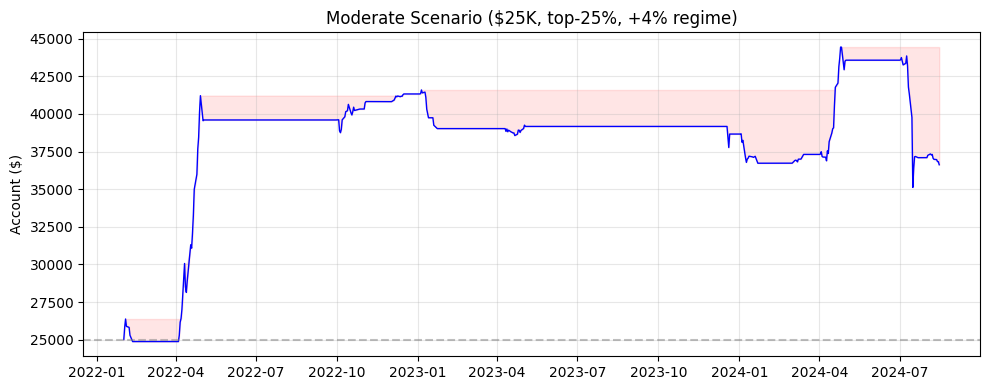

  [12s] 58s]



In [11]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
print("="*70)
print("EQUITY CURVES + DYNAMIC REGIME")
print("="*70)

def run_equity_sim(trades_df, start_bal, pos_size, max_pos, label, spy_regime_pct=None):
    """Sequential equity sim. Returns dict of results."""
    if len(trades_df)<5: return None
    ws=trades_df.sort_values(['entry_date','score'],ascending=[True,False]).reset_index(drop=True)
    cash=float(start_bal); positions=[]; trade_log=[]; daily_eq=[]
    if spy_close is not None:
        dates=sorted(spy_close.index[(spy_close.index>=ws['entry_date'].min())&(spy_close.index<=ws['exit_date'].max())])
    else:
        dates=sorted(set(ws['entry_date'].tolist()+ws['exit_date'].tolist()))
    taken=set(); regime_off_until=None

    for dt in dates:
        # Dynamic regime check
        if spy_regime_pct is not None and spy_close is not None:
            sp10=spy_close.loc[:dt]
            if len(sp10)>10:
                spy_10d=(float(sp10.iloc[-1])-float(sp10.iloc[-11]))/float(sp10.iloc[-11]) if float(sp10.iloc[-11])>0 else 0
                if spy_10d>spy_regime_pct:
                    # Close all open positions at today's price
                    for pos in positions:
                        # Early close — use today's price
                        tk_p=price_dict.get(pos['ticker'])
                        if tk_p is not None:
                            px_t=tk_p['Close'] if 'Close' in tk_p.columns else tk_p.iloc[:,0]
                            cp=px_t.asof(dt)
                            if pd.notna(cp):
                                early_pnl=(pos['entry_p']-float(cp))*pos['shares']
                                cash+=pos['entry_val']+early_pnl
                                trade_log.append({**pos,'pnl':early_pnl,'early_close':True})
                            else:
                                cash+=pos['entry_val']+pos['pnl']
                                trade_log.append(pos)
                        else:
                            cash+=pos['entry_val']+pos['pnl']; trade_log.append(pos)
                    positions=[]
                    # Wait until SPY 5d turns negative
                    regime_off_until='wait_neg'
                    continue
            if regime_off_until=='wait_neg' and len(sp10)>5:
                sp5v=float(sp10.iloc[-6])
                spy_5d=(float(sp10.iloc[-1])-sp5v)/sp5v if sp5v>0 else 0
                if spy_5d<0: regime_off_until=None
                else:
                    # Still waiting — compute daily equity with no positions
                    daily_eq.append({'date':dt,'equity':cash,'n_pos':0})
                    continue

        # Close exited positions
        still_open=[]
        for pos in positions:
            if dt>=pos['exit_date']:
                cash+=pos['entry_val']+pos['pnl']; trade_log.append(pos)
            else: still_open.append(pos)
        positions=still_open
        # Fill slots
        if len(positions)<max_pos and regime_off_until is None:
            open_tk={p['ticker'] for p in positions}
            for tidx in range(len(ws)):
                if tidx in taken or len(positions)>=max_pos: continue
                t_row=ws.iloc[tidx]
                ed=t_row['entry_date']
                if ed>dt or (dt-ed).days>30: continue
                if t_row['ticker'] in open_tk: continue
                # 2% max loss cap
                max_shares_by_risk=int(start_bal*0.02/(t_row['entry_price']*STOP_LOSS)) if t_row['entry_price']>0 else 0
                shares=min(int(pos_size/t_row['entry_price']),max_shares_by_risk) if t_row['entry_price']>0 else 0
                if shares==0: continue
                if cash<shares*t_row['entry_price']*0.5: continue
                ev=shares*t_row['entry_price']; pv=shares*t_row['pnl_per_share']
                cash-=ev
                positions.append({'ticker':t_row['ticker'],'entry_p':t_row['entry_price'],'shares':shares,
                    'entry_date':ed,'exit_date':t_row['exit_date'],'entry_val':ev,'pnl':pv,
                    'sector':t_row['sector'],'stopped':t_row['stopped'],'profit_taken':t_row['profit_taken']})
                taken.add(tidx); open_tk.add(t_row['ticker'])
        # MTM
        pv=0
        for pos in positions:
            tk_p=price_dict.get(pos['ticker'])
            if tk_p is not None:
                px_t=tk_p['Close'] if 'Close' in tk_p.columns else tk_p.iloc[:,0]
                cp=px_t.asof(dt)
                if pd.notna(cp): pv+=(pos['entry_p']-float(cp))*pos['shares']
        teq=cash+sum(p['entry_val'] for p in positions)+pv
        daily_eq.append({'date':dt,'equity':teq,'n_pos':len(positions)})
    # Close remaining
    for pos in positions: trade_log.append(pos)
    if not daily_eq: return None
    eq=pd.DataFrame(daily_eq); eq['date']=pd.to_datetime(eq['date']); eq=eq.sort_values('date')
    peak=eq['equity'].cummax(); dd=eq['equity']-peak
    max_dd=dd.min(); max_dd_pct=max_dd/peak.max() if peak.max()>0 else 0
    yrs=max((eq['date'].iloc[-1]-eq['date'].iloc[0]).days/365,0.5)
    ann=(eq['equity'].iloc[-1]/start_bal-1)/yrs
    calmar=ann/abs(max_dd_pct) if max_dd<0 else np.nan
    return {'label':label,'start':start_bal,'end':float(eq['equity'].iloc[-1]),
        'ret':(eq['equity'].iloc[-1]-start_bal)/start_bal,'ann':ann,'max_dd':max_dd,
        'max_dd_pct':max_dd_pct,'calmar':calmar,'trades':len(trade_log),
        'avg_pos':eq['n_pos'].mean(),'eq_df':eq,'trade_log':trade_log}

# Dynamic regime diagnostic: when would each threshold have fired?
if spy_close is not None and len(wf_top)>0:
    print("  REGIME DIAGNOSTIC (when would triggers fire?):")
    bad_qs=[q for q in wf_top['quarter'].unique() if wf_top[wf_top['quarter']==q]['pnl_per_share'].mean()<-0.5]
    for q in bad_qs:
        try:
            qp=pd.Period(q); spy_q=spy_close.loc[qp.start_time:qp.end_time]
            for thr_pct in [0.03,0.04,0.05]:
                for i in range(10,len(spy_q)):
                    r10=(float(spy_q.iloc[i])-float(spy_q.iloc[i-10]))/float(spy_q.iloc[i-10])
                    if r10>thr_pct:
                        day_num=i
                        print(f"    {q} @ {thr_pct:.0%}: triggers day {day_num} ({spy_q.index[i].date()})")
                        break
                else:
                    print(f"    {q} @ {thr_pct:.0%}: never triggers")
        except: pass

# Run 4 account scenarios × medium regime check
print(f"\n  ACCOUNT SCENARIOS (top-25% trades, +4% regime check):")
scenarios=[
    ('Conservative'  , 10000, 2000, 3),
    ('Moderate'      , 25000, 5000, 5),
    ('Aggressive'    , 50000, 8000, 5),
]
eq_results={}
for lbl,bal,ps,mp in scenarios:
    r=run_equity_sim(wf_top,bal,ps,mp,lbl,spy_regime_pct=0.04)
    if r:
        eq_results[lbl]=r
        print(f"    {lbl:<14} ${bal:>6,}→${r['end']:>8,.0f} ({r['ret']:+.0%}) DD=${r['max_dd']:>7,.0f} ({r['max_dd_pct']:.0%}) Cal={r['calmar']:.2f} trades={r['trades']}")

# Ramp-up scenario
print(f"\n  RAMP-UP ($5K start, scale 25% after profitable Q):")
if len(wf_top)>10:
    ws_ramp=wf_top.sort_values('entry_date').reset_index(drop=True)
    ramp_bal=5000; ramp_ps=1000; ramp_mp=3; ramp_cap=5000
    ramp_eq=[]; ramp_trades=0
    # Run quarter by quarter
    for q in sorted(wf_top['quarter'].unique()):
        q_trades=wf_top[wf_top['quarter']==q].sort_values('score',ascending=False)
        q_pnl=0; q_count=0
        if ramp_bal<100: ramp_eq.append({'quarter':q,'balance':ramp_bal,'q_pnl':0,'ps':ramp_ps}); continue
        for _,row in q_trades.iterrows():
            if q_count>=ramp_mp*4: break  # Max trades per quarter
            shares=min(int(ramp_ps/row['entry_price']),int(ramp_bal*0.02/(row['entry_price']*STOP_LOSS))) if row['entry_price']>0 else 0
            if shares==0: continue
            trade_pnl=shares*row['pnl_per_share']
            ramp_bal+=trade_pnl; q_pnl+=trade_pnl; q_count+=1; ramp_trades+=1
        ramp_eq.append({'quarter':q,'balance':ramp_bal,'q_pnl':q_pnl,'ps':ramp_ps})
        if q_pnl>0: ramp_ps=min(int(ramp_ps*1.25),ramp_cap)  # Scale up after win
        # Hold flat after loss (don't decrease)
    ramp_df=pd.DataFrame(ramp_eq)
    if len(ramp_df)>0:
        print(f"    Start: $5,000 | End: ${ramp_bal:,.0f} ({(ramp_bal-5000)/5000:+.0%})")
        print(f"    Position size: $1,000 → ${ramp_ps:,}")
        print(f"    Trades: {ramp_trades}")
        for _,r in ramp_df.iterrows():
            print(f"      {r['quarter']}: ${r['balance']:>8,.0f} (Q P&L ${r['q_pnl']:+,.0f}, size ${r['ps']:,})")

# Best scenario equity curve plot
best_sc=eq_results.get('Moderate')
if best_sc and 'eq_df' in best_sc:
    eq=best_sc['eq_df']
    fig,ax=plt.subplots(figsize=(10,4))
    ax.plot(eq['date'],eq['equity'],color='blue',linewidth=1)
    ax.axhline(best_sc['start'],color='gray',linestyle='--',alpha=0.5)
    pk=eq['equity'].cummax()
    ax.fill_between(eq['date'],eq['equity'],pk,alpha=0.1,color='red')
    ax.set_title(f"Moderate Scenario ($25K, top-25%, +4% regime)")
    ax.set_ylabel('Account ($)'); ax.grid(True,alpha=0.3); plt.tight_layout()
    try: plt.savefig(os.path.join(CACHE_DIR,'equity_v17.png'),dpi=150)
    except: pass
    plt.show()

print(f"  [{time.time()-t0:.0f}s] {elapsed()}")
print()


In [12]:
# ═══════════════════════════════════════════════════════════════
# DIAGNOSTICS (tech-only, staged entry, SPY corr, earnings proximity)


In [13]:
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
print("="*70)
print("DIAGNOSTICS")
print("="*70)

# Tech-only WF
if len(wf_top)>10 and 'sector' in wf_top.columns:
    tech=wf_top[wf_top['sector']=='Technology']
    if len(tech)>10:
        r_tech=run_equity_sim(tech,25000,5000,5,'Tech-only',spy_regime_pct=0.04)
        if r_tech:
            print(f"\n  TECH-ONLY: {len(tech)} trades → ${r_tech['end']:,.0f} ({r_tech['ret']:+.0%}) DD={r_tech['max_dd_pct']:.0%} Cal={r_tech['calmar']:.2f}")

# Staged entry diagnostic
print(f"\n  STAGED ENTRY (enter after 2% drop in 5d):")
if len(all_wf_trades)>20:
    immediate_pnl=[]; confirmed_pnl=[]; confirmed_count=0; missed=0
    for t in all_wf_trades:
        immediate_pnl.append(t['pnl_per_share'])
        tk=t['ticker']
        if tk not in price_dict: continue
        pxd2=price_dict[tk]; px2=pxd2['Close'] if 'Close' in pxd2.columns else pxd2.iloc[:,0]
        ed=t['entry_date']
        if ed not in px2.index: continue
        si=px2.index.get_loc(ed)
        # Check if stock drops 2% in next 5 days
        confirmed=False
        for di in range(1,min(6,len(px2)-si)):
            if (float(px2.iloc[si+di])-float(px2.iloc[si]))/float(px2.iloc[si])<=-0.02:
                confirmed=True; break
        if confirmed:
            confirmed_pnl.append(t['pnl_per_share']); confirmed_count+=1
        else: missed+=1
    if confirmed_count>=10:
        ia=np.array(immediate_pnl); ca=np.array(confirmed_pnl)
        print(f"    Immediate: n={len(ia)} win={(ia>0).mean():.0%} avg=${ia.mean():+.2f}/sh")
        print(f"    Confirmed: n={len(ca)} win={(ca>0).mean():.0%} avg=${ca.mean():+.2f}/sh (missed {missed})")

# SPY monthly correlation
if best_sc and 'eq_df' in best_sc and spy_close is not None:
    eq=best_sc['eq_df'].copy()
    eq['month']=eq['date'].dt.to_period('M')
    eq_monthly=eq.groupby('month')['equity'].agg(['first','last'])
    eq_monthly['ret']=(eq_monthly['last']-eq_monthly['first'])/eq_monthly['first']
    spy_monthly=spy_close.resample('M').agg(['first','last'])
    spy_monthly.columns=['first','last']
    spy_monthly['ret']=(spy_monthly['last']-spy_monthly['first'])/spy_monthly['first']
    spy_monthly.index=spy_monthly.index.to_period('M')
    common=eq_monthly.index.intersection(spy_monthly.index)
    if len(common)>5:
        corr=np.corrcoef(eq_monthly.loc[common,'ret'].values,spy_monthly.loc[common,'ret'].values)[0,1]
        print(f"\n  SPY MONTHLY CORRELATION: {corr:.2f}")
        if corr<-0.3: print(f"    → Useful portfolio hedge")
        elif abs(corr)<0.2: print(f"    → Market-neutral")
        else: print(f"    → Correlated with market (unexpected for short strategy)")

# Earnings proximity (try to download earnings dates)
print(f"\n  EARNINGS PROXIMITY:")
earn_dates=cache.get('earnings_dates',{})
if not earn_dates and len(wf_top)>0:
    # Download for tickers in walk-forward
    wf_tickers=list(wf_top['ticker'].unique())[:100]  # Cap at 100 to limit time
    print(f"    Downloading earnings dates for {len(wf_tickers)} tickers...")
    for tk in wf_tickers:
        try:
            tkr=yf.Ticker(tk)
            cal=tkr.calendar
            if cal is not None and not cal.empty:
                if 'Earnings Date' in cal.index:
                    ed_val=cal.loc['Earnings Date']
                    if hasattr(ed_val,'tolist'): earn_dates[tk]=ed_val.tolist()
                    else: earn_dates[tk]=[ed_val]
            # Also try earnings_dates attribute
            ehist=tkr.earnings_dates
            if ehist is not None and len(ehist)>0:
                earn_dates[tk]=sorted(ehist.index.tolist())
        except: pass
    cache['earnings_dates']=earn_dates; save_cache()
    print(f"    Got dates for {len(earn_dates)} tickers")

if earn_dates and len(wf_top)>10:
    near_earn=[]; far_earn=[]
    for _,row in wf_top.iterrows():
        tk=row['ticker']; ed=row['entry_date']
        if tk not in earn_dates: continue
        # Find next earnings after entry
        try:
            tk_earns=[pd.Timestamp(e) for e in earn_dates[tk]]
            tk_earns=[e for e in tk_earns if e>=ed]
        except: continue
        if not tk_earns: continue
        days_to_earn=(tk_earns[0]-ed).days
        if days_to_earn<=15: near_earn.append(row)
        elif days_to_earn>30: far_earn.append(row)
    if len(near_earn)>=5 and len(far_earn)>=5:
        ne=pd.DataFrame(near_earn); fe=pd.DataFrame(far_earn)
        print(f"    Near earnings (≤15d): n={len(ne)} win={(ne['pnl_per_share']>0).mean():.0%} avg=${ne['pnl_per_share'].mean():+.2f}/sh stop={ne['stopped'].mean():.0%}")
        print(f"    Far from earnings (>30d): n={len(fe)} win={(fe['pnl_per_share']>0).mean():.0%} avg=${fe['pnl_per_share'].mean():+.2f}/sh stop={fe['stopped'].mean():.0%}")
    else:
        print(f"    Insufficient earnings data (near={len(near_earn)}, far={len(far_earn)})")
else:
    print(f"    No earnings dates available")

print(f"  [{time.time()-t0:.0f}s] {elapsed()}")
print()


DIAGNOSTICS

  TECH-ONLY: 51 trades → $32,563 (+30%) DD=-8% Cal=1.55

  STAGED ENTRY (enter after 2% drop in 5d):
    Immediate: n=520 win=62% avg=$+0.71/sh
    Confirmed: n=355 win=75% avg=$+1.46/sh (missed 165)

  SPY MONTHLY CORRELATION: -0.40
    → Useful portfolio hedge

  EARNINGS PROXIMITY:
    Got dates for 0 tickers
    No earnings dates available
  [8s] 7s]



In [14]:
# ═══════════════════════════════════════════════════════════════
# HOLDOUT + RESULTS


In [15]:
# ═══════════════════════════════════════════════════════════════
print("HOLDOUT...")
ho_auc=np.nan
try:
    if best_v_t in df_hold.columns and df_hold[best_v_t].sum()>=10 and 'vuln_score' in df_hold.columns:
        yh=df_hold[best_v_t].fillna(0).astype(int)
        hp=df_hold['vuln_score'].values; valid=~np.isnan(hp)
        if valid.sum()>=20 and yh[valid].sum()>=5:
            ho_auc=roc_auc_score(yh[valid],hp[valid])
            htk=df_hold['ticker'].values[valid]; utk=np.unique(htk)
            tidx2={t:np.where(htk==t)[0] for t in utk}; hb=[]
            for _ in range(N_BOOT):
                bt2=np.random.choice(utk,len(utk),replace=True); idx=np.concatenate([tidx2[t] for t in bt2])
                if len(idx)>0 and yh.values[valid][idx].sum()>0 and yh.values[valid][idx].sum()<len(idx):
                    try: hb.append(roc_auc_score(yh.values[valid][idx],hp[valid][idx]))
                    except: pass
            hcl=np.percentile(hb,2.5) if hb else ho_auc; hch=np.percentile(hb,97.5) if hb else ho_auc
            print(f"  Holdout: {ho_auc:.3f} [{hcl:.3f},{hch:.3f}]")
            print(f"  Dev:     {best_v_r['mauc']:.3f} [{best_v_r['clo']:.3f},{best_v_r['chi']:.3f}]")
            gap=best_v_r['mauc']-ho_auc
            if abs(gap)<0.05: print(f"  ✅ Consistent ({gap:+.3f})")
            else: print(f"  ⚠️  Gap: {gap:+.3f}")
except Exception as e: print(f"  Holdout error: {e}")
print()

# FULL RESULTS
ba=best_v_r['mauc']; cl=best_v_r['clo']
print("█"*70)
print("  DROP SCORE v17 — FULL RESULTS")
print("█"*70)
print(f"""
DATA: {df_q['ticker'].nunique()} stocks | {len(df_dev):,} dev + {len(df_hold):,} hold
VULN: {best_v_t} Dev={ba:.3f} [{cl:.3f},{best_v_r['chi']:.3f}] Hold={ho_auc:.3f}
Features: {topf_v}
""")
va_tgts_r=[t for t in v_results if t.startswith('voladj_')]
bva=max(va_tgts_r,key=lambda k:v_results[k]['mauc']) if va_tgts_r else None
va_auc=v_results[bva]['mauc'] if bva else 0
print(f"VOL-ADJUSTED: {bva or 'N/A'} AUC={va_auc:.3f}")
if len(wf_df)>0:
    print(f"""
WALK-FORWARD: {len(wf_df)} trades (1-day delay, vol floor {VOL_FLOOR:,})
  Full:    win={(wf_df['pnl_per_share']>0).mean():.0%} avg=${wf_df['pnl_per_share'].mean():+.2f}/sh ({wf_df['pnl_pct'].mean()*100:+.1f}%) stops={wf_df['stopped'].mean():.0%}
  Top 25%: win={(wf_top['pnl_per_share']>0).mean():.0%} avg=${wf_top['pnl_per_share'].mean():+.2f}/sh ({wf_top['pnl_pct'].mean()*100:+.1f}%) stops={wf_top['stopped'].mean():.0%}
  Quarters: {(wf_top.groupby('quarter')['pnl_per_share'].sum()>0).sum()}/{wf_top['quarter'].nunique()} profitable
""")
# Print scenarios
for lbl,r in eq_results.items():
    print(f"  {lbl}: ${r['start']:,}→${r['end']:,.0f} ({r['ret']:+.0%}) DD={r['max_dd_pct']:.0%} Calmar={r['calmar']:.2f}")

print(f"""
VERDICT:
  Signal: {'✅' if ba>=0.70 else '⚠️'} Dev={ba:.3f} Hold={ho_auc:.3f} VolAdj={va_auc:.3f}
  Alpha: {'✅' if len(wf_top)>0 and wf_top['pnl_per_share'].mean()>0 else '⚠️'}
  Conviction: Top 25% outperforms → trade only highest-scored picks
""")

# Top 20 trades inline
if len(wf_top)>0:
    print("FIRST 20 TRADES (top-25% conviction):")
    for i,(_,r) in enumerate(wf_top.sort_values('entry_date').head(20).iterrows()):
        ex='STOP' if r['stopped'] else 'PT' if r['profit_taken'] else 'EXP'
        print(f"  {r['ticker']:<6} {str(r['entry_date'])[:10]} ${r['entry_price']:>6.0f}→${r['exit_price']:>6.0f} {ex:<4} ${r['pnl_per_share']:+.2f}/sh ({r['pnl_pct']*100:+.1f}%)")

# Save to Drive
with open(os.path.join(CACHE_DIR,'v17_results.pkl'),'wb') as f:
    pickle.dump({'best_v_t':best_v_t,'best_v_r':best_v_r,'topf_v':topf_v,'K':K,
        'ho_auc':ho_auc,'v_results':v_results,'wf_trades':all_wf_trades,
        'wf_top_trades':wf_top.to_dict('records') if len(wf_top)>0 else [],
        'eq_results':{k:{kk:vv for kk,vv in v.items() if kk!='eq_df' and kk!='trade_log'} for k,v in eq_results.items()},
        'fcols_q':fcols_q,'tgt_rates':tgt_rates},f)

print(f"\nTotal: {(time.time()-t_start)/60:.1f} min")
print(f"Next run (voladj cached, skip list active): ~9 min")
print("Drop Score v17 complete.")


HOLDOUT...
  Holdout: 0.842 [0.803,0.882]
  Dev:     0.816 [0.791,0.832]
  ✅ Consistent (-0.026)

██████████████████████████████████████████████████████████████████████
  DROP SCORE v17 — FULL RESULTS
██████████████████████████████████████████████████████████████████████

DATA: 1657 stocks | 18,183 dev + 2,867 hold
VULN: exdrop_15_10d Dev=0.816 [0.791,0.832] Hold=0.842
Features: ['vol_60d', 'vol_30d', 'roa_x_vol', 'roa', 'op_margin', 'gap_count_30d', 'sga_to_rev', 'cash_pct', 'margin_x_vol', 'dd_from_high']

VOL-ADJUSTED: voladj_2sig_42d AUC=0.677

WALK-FORWARD: 520 trades (1-day delay, vol floor 500,000)
  Full:    win=62% avg=$+0.71/sh (+1.9%) stops=53%
  Top 25%: win=73% avg=$+2.50/sh (+5.7%) stops=48%
  Quarters: 4/8 profitable

  Conservative: $10,000→$12,723 (+27%) DD=-18% Calmar=0.58
  Moderate: $25,000→$36,621 (+46%) DD=-21% Calmar=0.87
  Aggressive: $50,000→$73,363 (+47%) DD=-21% Calmar=0.88

VERDICT:
  Signal: ✅ Dev=0.816 Hold=0.842 VolAdj=0.677
  Alpha: ✅
  Conviction: Top 2